Implement forward propagation and backpropagation using TensorFlow/Keras. Analyze the effect of different learning rates and the number of epochs on model performance.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Preprocess: Normalize to [0, 1] and flatten images from 28x28 to 784
X = x_train.reshape(-1, 784).astype('float32') / 255.0
# Convert labels to one-hot encoding for classification
y = keras.utils.to_categorical(y_train, 10)

def create_model():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
learning_rates = [0.1, 0.01, 0.001]
epochs_to_test = [5, 10]
results = {}

for lr in learning_rates:
    for epochs in epochs_to_test:
        model = create_model()
        optimizer = keras.optimizers.Adam(learning_rate=lr)
        # Using categorical_crossentropy for MNIST classification
        model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

        print(f"Training MNIST - LR: {lr}, Epochs: {epochs}...")
        history = model.fit(X, y, epochs=epochs, batch_size=128, verbose=0, validation_split=0.1)

        key = f"LR: {lr}, Epochs: {epochs}"
        results[key] = history.history['loss']

Training MNIST - LR: 0.1, Epochs: 5...
Training MNIST - LR: 0.1, Epochs: 10...
Training MNIST - LR: 0.01, Epochs: 5...
Training MNIST - LR: 0.01, Epochs: 10...
Training MNIST - LR: 0.001, Epochs: 5...
Training MNIST - LR: 0.001, Epochs: 10...


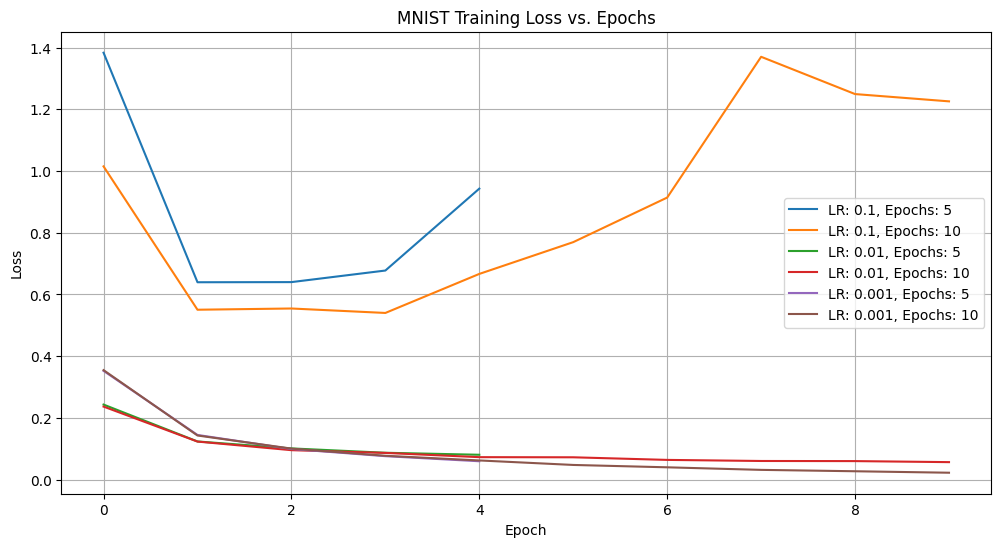

In [ ]:
plt.figure(figsize=(12, 6))
for label, losses in results.items():
    plt.plot(losses, label=label)

plt.title('MNIST Training Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()